# Quantium Task 2: Experimentation and Uplift Testing

## 1. Load data and define monthly store metrics

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell

# Set the shell to show all outputs, not just the last one
InteractiveShell.ast_node_interactivity = "all"

data = pd.read_csv("QVI_data.csv")
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


### 1.1 Load cleaned data

In [4]:
data["DATE"] = pd.to_datetime(data["DATE"])
data["DATE"].dtype

dtype('<M8[us]')

### 1.2 Create monthly store-level measures

In [5]:
data["YEARMONTH"] = data["DATE"].dt.year * 100 + data["DATE"].dt.month
data[["DATE", "YEARMONTH"]].head()

,DATE,YEARMONTH
0,2018-10-17,201810
1,2018-09-16,201809
2,2019-03-07,201903
3,2019-03-08,201903
4,2018-11-02,201811


In [6]:
measure_over_time = (
    data.groupby(["STORE_NBR", "YEARMONTH"])
    .agg(
        totSales=("TOT_SALES", "sum"),
        nCustomers=("LYLTY_CARD_NBR", "nunique"),
        nTxn=("TXN_ID", "nunique"),
        nChips=("PROD_QTY", "sum")
    )
    .reset_index()
)

measure_over_time["nTxnPerCust"] = (
    measure_over_time["nTxn"] / measure_over_time["nCustomers"]
)

measure_over_time["nChipsPerTxn"] = (
    measure_over_time["nChips"] / measure_over_time["nTxn"]
)

measure_over_time["avgPricePerUnit"] = (
    measure_over_time["totSales"] / measure_over_time["nChips"]
)

measure_over_time.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [7]:
measure_over_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STORE_NBR        3169 non-null   int64  
 1   YEARMONTH        3169 non-null   int32  
 2   totSales         3169 non-null   float64
 3   nCustomers       3169 non-null   int64  
 4   nTxn             3169 non-null   int64  
 5   nChips           3169 non-null   int64  
 6   nTxnPerCust      3169 non-null   float64
 7   nChipsPerTxn     3169 non-null   float64
 8   avgPricePerUnit  3169 non-null   float64
dtypes: float64(4), int32(1), int64(4)
memory usage: 210.6 KB


In [8]:
measure_over_time.describe()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
count,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000,3169.000000
mean,136.802461,201856.483749,610.007889,69.826128,83.031556,159.269170,1.141307,1.813254,3.805827
std,78.418604,47.040465,389.699478,36.817352,47.918428,100.476057,0.111341,0.295347,0.494938
min,1.000000,201807.000000,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,68.000000,201809.000000,260.000000,41.000000,43.000000,70.000000,1.041667,1.696429,3.447368
50%,137.000000,201812.000000,674.600000,79.000000,96.000000,182.000000,1.125000,1.974790,3.589524
75%,204.000000,201903.000000,928.200000,102.000000,127.000000,252.000000,1.233645,2.000000,4.365546
max,272.000000,201906.000000,1659.600000,150.000000,188.000000,377.000000,1.468085,2.500000,5.350000


In [9]:
measure_over_time["YEARMONTH"].min(), measure_over_time["YEARMONTH"].max()

(np.int32(201807), np.int32(201906))

## 2. Define trial stores and pre-trial period

### 2.1 Define trial stores
### 2.2 Define pre-trial and trial periods
### 2.3 Keep stores with complete pre-trial observations

In [10]:
trial_stores = [77, 86, 88]
pre_trial_end = 201901
trial_start = 201902
trial_end = 201904

In [11]:
pre_trial = measure_over_time[measure_over_time["YEARMONTH"] <= pre_trial_end].copy()
pre_trial.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [12]:
store_counts = pre_trial.groupby("STORE_NBR")["YEARMONTH"].nunique()
store_counts.head()

STORE_NBR
1    7
2    7
3    7
4    7
5    7
Name: YEARMONTH, dtype: int64

In [14]:
full_observation_stores = store_counts[store_counts == pre_trial["YEARMONTH"].nunique()].index
len(full_observation_stores)

260

In [15]:
pre_trial_full = pre_trial[pre_trial["STORE_NBR"].isin(full_observation_stores)].copy()
pre_trial_full.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


### 2.4 Check whether trial stores have complete records in pre-trial 

In [16]:
pre_trial_full[pre_trial_full["STORE_NBR"].isin(trial_stores)] \
    .groupby("STORE_NBR")["YEARMONTH"].nunique()

STORE_NBR
77    7
86    7
88    7
Name: YEARMONTH, dtype: int64

In [19]:
measure_over_time.head()
measure_over_time["YEARMONTH"].min(), measure_over_time["YEARMONTH"].max()
pre_trial_full[pre_trial_full["STORE_NBR"].isin(trial_stores)].groupby("STORE_NBR")["YEARMONTH"].nunique()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


(np.int32(201807), np.int32(201906))

STORE_NBR
77    7
86    7
88    7
Name: YEARMONTH, dtype: int64

## 3. Select control stores

### 3.1 Compare stores using pre-trial performance

In [20]:
def calculate_metric_score(pre_trial_df, trial_store, metric_col, excluded_stores):
    metric_pivot = pre_trial_df.pivot(
        index="YEARMONTH",
        columns="STORE_NBR",
        values=metric_col
    )

    trial_series = metric_pivot[trial_store]
    results = []

    for candidate_store in metric_pivot.columns:
        if candidate_store == trial_store or candidate_store in excluded_stores:
            continue

        candidate_series = metric_pivot[candidate_store]

        # Trend similarity
        corr = trial_series.corr(candidate_series)
        corr_score = (corr + 1) / 2

        # Level similarity
        magnitude_score = np.mean(
            np.minimum(trial_series.values, candidate_series.values) /
            np.maximum(trial_series.values, candidate_series.values)
        )

        final_score = (corr_score + magnitude_score) / 2

        results.append({
            "trialStore": trial_store,
            "candidateStore": candidate_store,
            "metric": metric_col,
            "correlation": corr,
            "corrScore": corr_score,
            "magnitudeScore": magnitude_score,
            "finalMetricScore": final_score
        })

    return pd.DataFrame(results).sort_values("finalMetricScore", ascending=False)

The similarity between stores was assessed using both trend similarity and magnitude similarity during the pre-trial period.

- Correlation was used to compare the shape of monthly performance over time
- Magnitude similarity was used to compare the overall level of performance

### 3.4 Select control store for trial store 77

In [21]:
sales_scores_77 = calculate_metric_score(
    pre_trial_df=pre_trial_full,
    trial_store=77,
    metric_col="totSales",
    excluded_stores=trial_stores
)

sales_scores_77.head(10)

,trialStore,candidateStore,metric,correlation,corrScore,magnitudeScore,finalMetricScore
218,77,233,totSales,0.903774,0.951887,0.921807,0.936847
46,77,50,totSales,0.763866,0.881933,0.874618,0.878276
38,77,41,totSales,0.783232,0.891616,0.816696,0.854156
49,77,53,totSales,0.532764,0.766382,0.872157,0.819270
249,77,265,totSales,0.639759,0.819880,0.801866,0.810873
156,77,167,totSales,0.657110,0.828555,0.779540,0.804048
42,77,46,totSales,0.435650,0.717825,0.876514,0.797170
176,77,187,totSales,0.460669,0.730334,0.862188,0.796261
105,77,115,totSales,0.689159,0.844579,0.738254,0.791417
101,77,111,totSales,0.519473,0.759736,0.818119,0.788928


In [22]:
customer_scores_77 = calculate_metric_score(
    pre_trial_df=pre_trial_full,
    trial_store=77,
    metric_col="nCustomers",
    excluded_stores=trial_stores
)

customer_scores_77.head(10)

,trialStore,candidateStore,metric,correlation,corrScore,magnitudeScore,finalMetricScore
218,77,233,nCustomers,0.990358,0.995179,0.982778,0.988978
38,77,41,nCustomers,0.844219,0.922110,0.944667,0.933388
238,77,254,nCustomers,0.916208,0.958104,0.853360,0.905732
15,77,17,nCustomers,0.747308,0.873654,0.921223,0.897438
105,77,115,nCustomers,0.718882,0.859441,0.927368,0.893405
78,77,84,nCustomers,0.858571,0.929286,0.849821,0.889553
101,77,111,nCustomers,0.685926,0.842963,0.922674,0.882819
156,77,167,nCustomers,0.717913,0.858956,0.888538,0.873747
25,77,27,nCustomers,0.686386,0.843193,0.897776,0.870484
134,77,145,nCustomers,0.681155,0.840578,0.899299,0.869938


### 3.3 Combine similarity scores across metrics

In [23]:
combined_scores_77 = sales_scores_77.merge(
    customer_scores_77,
    on=["trialStore", "candidateStore"],
    suffixes=("_sales", "_customers")
)

combined_scores_77["finalControlScore"] = combined_scores_77[
    ["finalMetricScore_sales", "finalMetricScore_customers"]
].mean(axis=1)

combined_scores_77 = combined_scores_77.sort_values(
    "finalControlScore",
    ascending=False
)

combined_scores_77.head(10)

,trialStore,candidateStore,metric_sales,correlation_sales,corrScore_sales,magnitudeScore_sales,finalMetricScore_sales,metric_customers,correlation_customers,corrScore_customers,magnitudeScore_customers,finalMetricScore_customers,finalControlScore
0,77,233,totSales,0.903774,0.951887,0.921807,0.936847,nCustomers,0.990358,0.995179,0.982778,0.988978,0.962913
2,77,41,totSales,0.783232,0.891616,0.816696,0.854156,nCustomers,0.844219,0.922110,0.944667,0.933388,0.893772
1,77,50,totSales,0.763866,0.881933,0.874618,0.878276,nCustomers,0.607391,0.803695,0.854727,0.829211,0.853743
8,77,115,totSales,0.689159,0.844579,0.738254,0.791417,nCustomers,0.718882,0.859441,0.927368,0.893405,0.842411
5,77,167,totSales,0.657110,0.828555,0.779540,0.804048,nCustomers,0.717913,0.858956,0.888538,0.873747,0.838897
3,77,53,totSales,0.532764,0.766382,0.872157,0.819270,nCustomers,0.602680,0.801340,0.909736,0.855538,0.837404
9,77,111,totSales,0.519473,0.759736,0.818119,0.788928,nCustomers,0.685926,0.842963,0.922674,0.882819,0.835873
13,77,17,totSales,0.842668,0.921334,0.610979,0.766157,nCustomers,0.747308,0.873654,0.921223,0.897438,0.831797
4,77,265,totSales,0.639759,0.819880,0.801866,0.810873,nCustomers,0.573460,0.786730,0.897944,0.842337,0.826605
6,77,46,totSales,0.435650,0.717825,0.876514,0.797170,nCustomers,0.550739,0.775370,0.917285,0.846327,0.821748


### 3.4 Create a reusable function for control store selection

In [24]:
def find_best_control_store(pre_trial_df, trial_store, excluded_stores):
    sales_scores = calculate_metric_score(
        pre_trial_df=pre_trial_df,
        trial_store=trial_store,
        metric_col="totSales",
        excluded_stores=excluded_stores
    )

    customer_scores = calculate_metric_score(
        pre_trial_df=pre_trial_df,
        trial_store=trial_store,
        metric_col="nCustomers",
        excluded_stores=excluded_stores
    )

    combined_scores = sales_scores.merge(
        customer_scores,
        on=["trialStore", "candidateStore"],
        suffixes=("_sales", "_customers")
    )

    combined_scores["finalControlScore"] = combined_scores[
        ["finalMetricScore_sales", "finalMetricScore_customers"]
    ].mean(axis=1)

    combined_scores = combined_scores.sort_values(
        "finalControlScore",
        ascending=False
    )

    return combined_scores

### 3.5 Rank candidate control stores for each trial store

In [48]:
control_77 = find_best_control_store(pre_trial_full, 77, trial_stores)
control_86 = find_best_control_store(pre_trial_full, 86, trial_stores)
control_88 = find_best_control_store(pre_trial_full, 88, trial_stores)

control_77.head(5), control_86.head(5), control_88.head(5)

(   trialStore  candidateStore metric_sales  correlation_sales  \
 0          77             233     totSales           0.903774   
 2          77              41     totSales           0.783232   
 1          77              50     totSales           0.763866   
 8          77             115     totSales           0.689159   
 5          77             167     totSales           0.657110   
 
    corrScore_sales  magnitudeScore_sales  finalMetricScore_sales  \
 0         0.951887              0.921807                0.936847   
 2         0.891616              0.816696                0.854156   
 1         0.881933              0.874618                0.878276   
 8         0.844579              0.738254                0.791417   
 5         0.828555              0.779540                0.804048   
 
   metric_customers  correlation_customers  corrScore_customers  \
 0       nCustomers               0.990358             0.995179   
 2       nCustomers               0.844219          

In [26]:
best_control_77 = control_77.iloc[0]["candidateStore"]
best_control_86 = control_86.iloc[0]["candidateStore"]
best_control_88 = control_88.iloc[0]["candidateStore"]

best_control_77, best_control_86, best_control_88

(np.int64(233), np.int64(155), np.int64(237))

The best control stores were selected based on their similarity to each trial store during the pre-trial period.

Similarity was assessed using both:
- monthly total sales
- monthly number of customers

The highest-ranked candidate for each trial store will be used as the control store in the next stage of the analysis.

## 4. Validate pre-trial similarity

### 4.1 Compare monthly sales before the trial

In [31]:
import matplotlib.dates as mdates

def plot_pretrial_metric(pretrial_df, trial_store, control_store, metric_col, title):
    trial_data = pretrial_df[pretrial_df["STORE_NBR"] == trial_store].copy()
    control_data = pretrial_df[pretrial_df["STORE_NBR"] == control_store].copy()

    # Convert YEARMONTH (e.g. 201807) to datetime
    trial_data["Month"] = pd.to_datetime(trial_data["YEARMONTH"].astype(str), format="%Y%m")
    control_data["Month"] = pd.to_datetime(control_data["YEARMONTH"].astype(str), format="%Y%m")

    # Sort by month to ensure the line is drawn correctly
    trial_data = trial_data.sort_values("Month")
    control_data = control_data.sort_values("Month")

    plt.figure(figsize=(10, 5))
    plt.plot(trial_data["Month"], trial_data[metric_col], marker="o", label=f"Trial Store {trial_store}")
    plt.plot(control_data["Month"], control_data[metric_col], marker="o", label=f"Control Store {control_store}")

    plt.xlabel("Month")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.legend()

    # Format x-axis as year-month
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

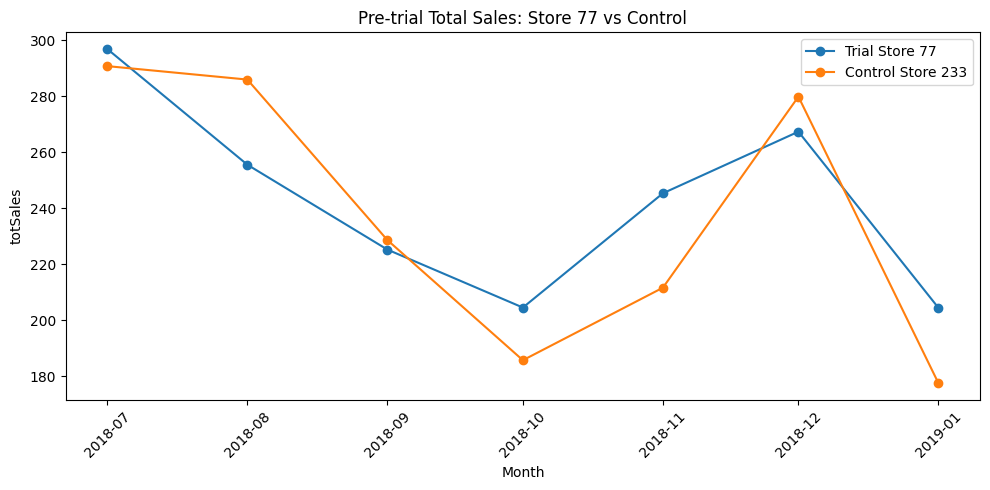

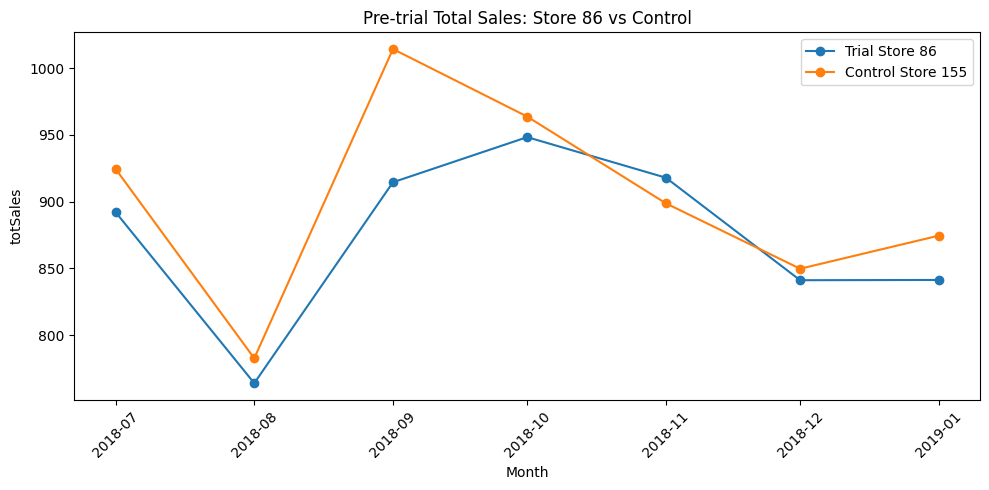

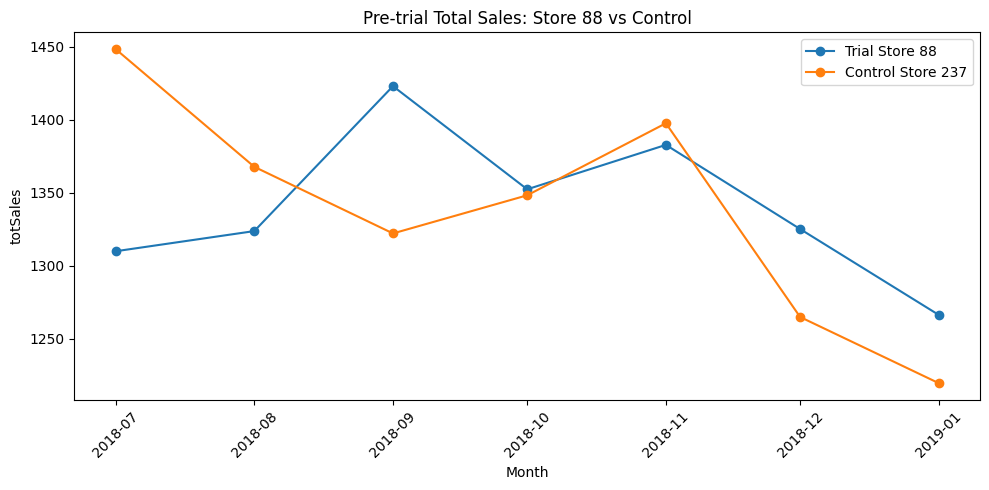

In [37]:
plot_pretrial_metric(
    pre_trial_full,
    77,
    best_control_77,
    "totSales",
    "Pre-trial Total Sales: Store 77 vs Control"
)

plot_pretrial_metric(
    pre_trial_full,
    86,
    best_control_86,
    "totSales",
    "Pre-trial Total Sales: Store 86 vs Control"
)

plot_pretrial_metric(
    pre_trial_full,
    88,
    best_control_88,
    "totSales",
    "Pre-trial Total Sales: Store 88 vs Control"
)

The pre-trial monthly sales trends were compared visually between each trial store and its matched control store.

A strong control store should show a similar sales level and a similar month-to-month pattern before the trial begins.

### 4.2 Compare monthly customer counts before the trial

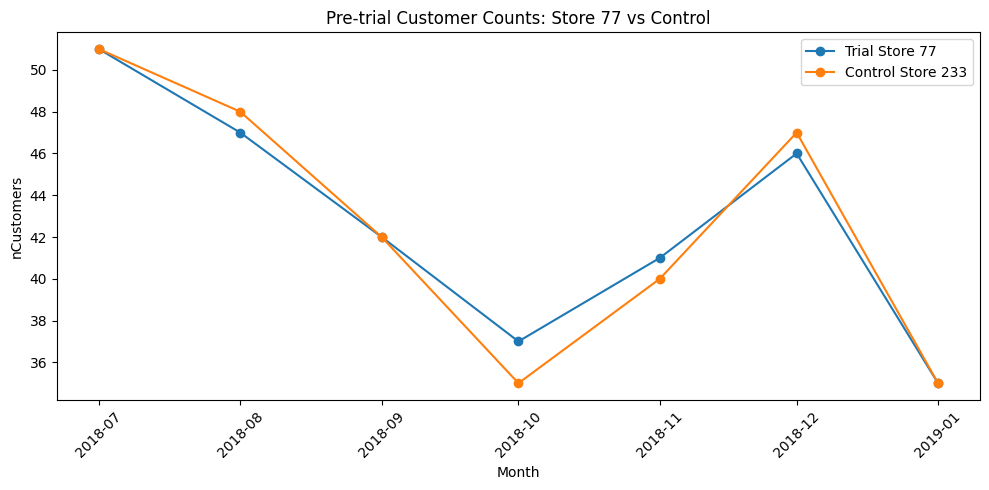

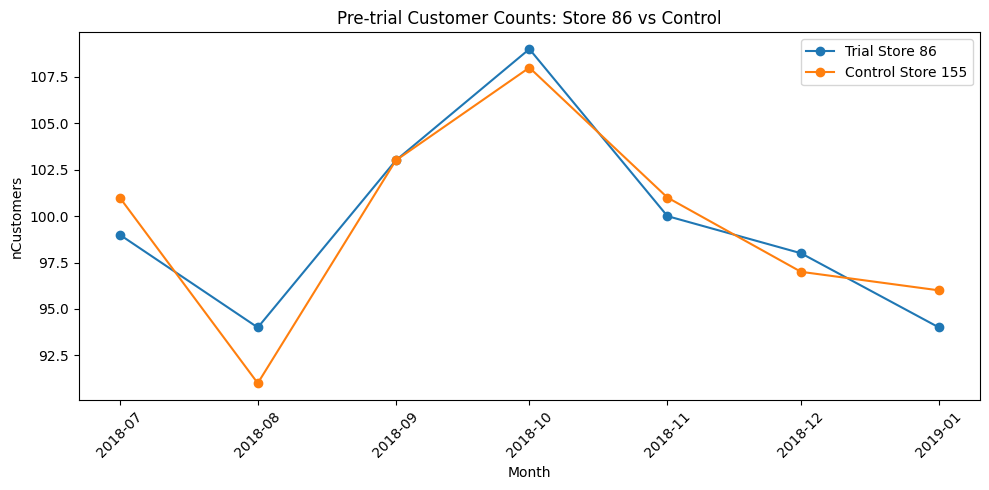

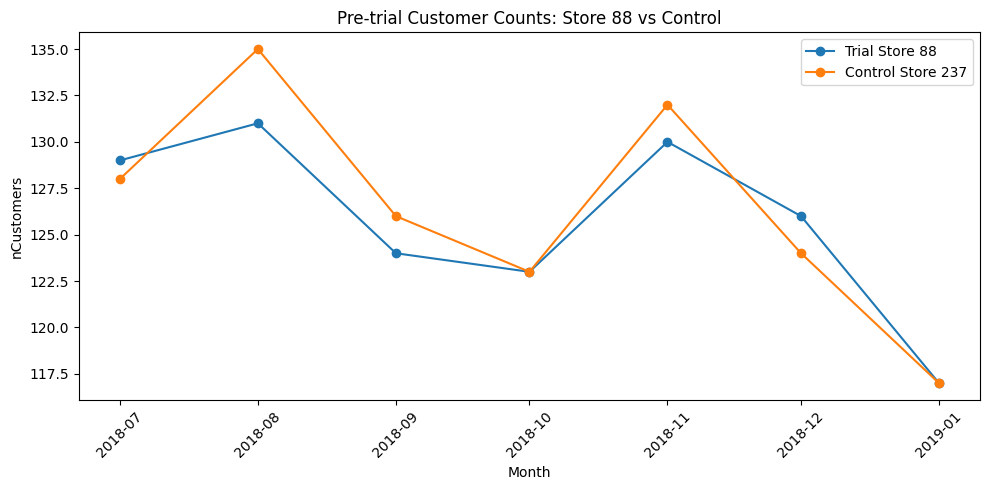

In [38]:
plot_pretrial_metric(
    pre_trial_full,
    77,
    best_control_77,
    "nCustomers",
    "Pre-trial Customer Counts: Store 77 vs Control"
)

plot_pretrial_metric(
    pre_trial_full,
    86,
    best_control_86,
    "nCustomers",
    "Pre-trial Customer Counts: Store 86 vs Control"
)

plot_pretrial_metric(
    pre_trial_full,
    88,
    best_control_88,
    "nCustomers",
    "Pre-trial Customer Counts: Store 88 vs Control"
)

In [ ]:
Customer count trends were also compared visually.

This helps confirm whether the matched control store is similar not only in sales performance, but also in customer traffic before the trial period.

### 4.3 Assess whether the trial and control stores are comparable

Based on the pre-trial visual comparison:

- Store 77 and its matched control store appear highly comparable in both sales and customer trends.
- Store 86 and its matched control store also appear to be well matched.
- Store 88 requires more careful interpretation, as the control match is weaker on sales trend than for the other two trial stores.

The visual validation supports using the selected control stores for the next stage of uplift assessment, although the results for Store 88 should be interpreted more cautiously.

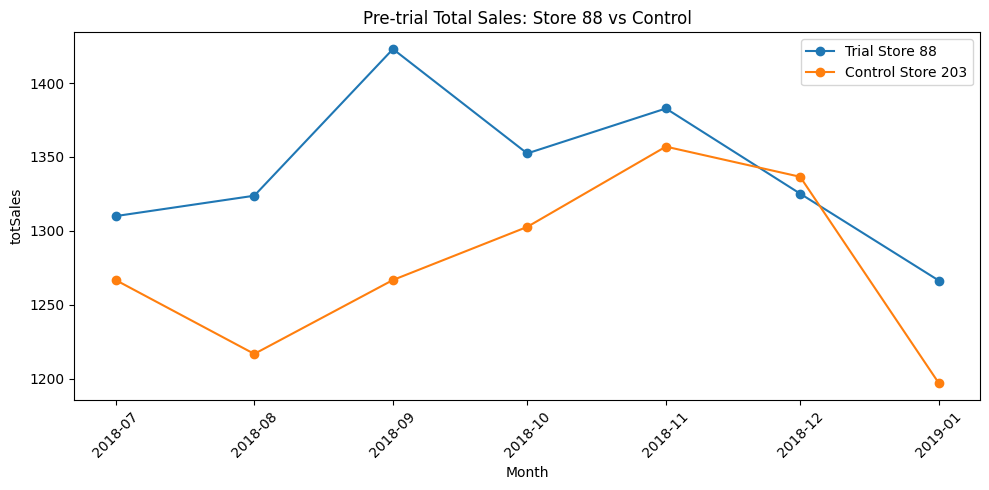

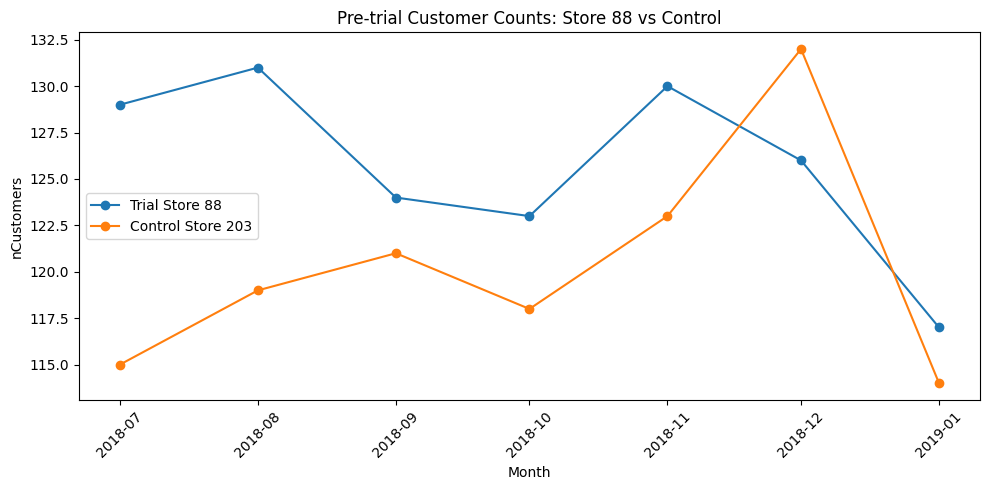

In [56]:
plot_pretrial_metric(
    pre_trial_full,
    88,
    control_88.iloc[3]["candidateStore"],
    "totSales",
    "Pre-trial Total Sales: Store 88 vs Control"
)
plot_pretrial_metric(
    pre_trial_full,
    88,
    control_88.iloc[3]["candidateStore"],
    "nCustomers",
    "Pre-trial Customer Counts: Store 88 vs Control"
)

For Store 88, no candidate control store appears as strong as the matched controls identified for Stores 77 and 86.

Although Store 237 achieved the highest composite similarity score, visual inspection suggests that the pre-trial sales relationship is less stable. Among the alternative candidates, Store 203 appears to provide a more balanced comparison in terms of pre-trial sales level and trend.

Therefore, the results for Store 88 should be interpreted with more caution than those for Stores 77 and 86.

In [ ]:
## 5. Evaluate trial uplift

### 5.1 Fix the final trial-control store pairs

In [57]:
final_controls = {
    77: 233,
    86: 155,
    88: 237
}

final_controls

{77: 233, 86: 155, 88: 237}

In [ ]:
### 5.2 Create a dataset for trial and control stores

In [60]:
selected_stores = [77, 86, 88, 233, 155, 237]

store_comparison = measure_over_time[
    measure_over_time["STORE_NBR"].isin(selected_stores)
].copy()

store_comparison.head()

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
880,77,201807,296.8,51,55,84,1.078431,1.527273,3.533333
881,77,201808,255.5,47,48,74,1.021277,1.541667,3.452703
882,77,201809,225.2,42,44,70,1.047619,1.590909,3.217143
883,77,201810,204.5,37,38,52,1.027027,1.368421,3.932692
884,77,201811,245.3,41,44,67,1.073171,1.522727,3.661194


In [61]:
pre_trial_data = store_comparison[store_comparison["YEARMONTH"] <= 201901].copy()
trial_period_data = store_comparison[
    (store_comparison["YEARMONTH"] >= 201902) &
    (store_comparison["YEARMONTH"] <= 201904)
].copy()

pre_trial_data.head(), trial_period_data.head()

(     STORE_NBR  YEARMONTH  totSales  nCustomers  nTxn  nChips  nTxnPerCust  \
 880         77     201807     296.8          51    55      84     1.078431   
 881         77     201808     255.5          47    48      74     1.021277   
 882         77     201809     225.2          42    44      70     1.047619   
 883         77     201810     204.5          37    38      52     1.027027   
 884         77     201811     245.3          41    44      67     1.073171   
 
      nChipsPerTxn  avgPricePerUnit  
 880      1.527273         3.533333  
 881      1.541667         3.452703  
 882      1.590909         3.217143  
 883      1.368421         3.932692  
 884      1.522727         3.661194  ,
      STORE_NBR  YEARMONTH  totSales  nCustomers  nTxn  nChips  nTxnPerCust  \
 887         77     201902     235.0          45    45      74     1.000000   
 888         77     201903     278.5          50    55      82     1.100000   
 889         77     201904     263.5          47    48    

## 6. Scale control stores to the trial store baseline

### 6.1 Calculate scaling factors using the pre-trial period

In [63]:
def calculate_scaling_factor(pretrial_df, trial_store, control_store, metric_col):
    trial_total = pretrial_df.loc[
        pretrial_df["STORE_NBR"] == trial_store, metric_col
    ].sum()

    control_total = pretrial_df.loc[
        pretrial_df["STORE_NBR"] == control_store, metric_col
    ].sum()

    return trial_total / control_total

In [64]:
sales_scaling_factors = {}
customer_scaling_factors = {}

for trial_store, control_store in final_controls.items():
    sales_scaling_factors[trial_store] = calculate_scaling_factor(
        pre_trial_data, trial_store, control_store, "totSales"
    )
    customer_scaling_factors[trial_store] = calculate_scaling_factor(
        pre_trial_data, trial_store, control_store, "nCustomers"
    )

sales_scaling_factors, customer_scaling_factors

({77: np.float64(1.023617303289553),
  86: np.float64(0.9700651481287743),
  88: np.float64(1.001558330664959)},
 {77: np.float64(1.0033557046979866),
  86: np.float64(1.0),
  88: np.float64(0.9943502824858758)})

## 7. Estimate expected trial-period performance

### 7.1 Create expected sales and customer counts from the scaled control stores

In [67]:
def create_trial_comparison_df(full_df, trial_store, control_store, metric_col, scaling_factor):
    trial_df = full_df[full_df["STORE_NBR"] == trial_store][["YEARMONTH", metric_col]].copy()
    control_df = full_df[full_df["STORE_NBR"] == control_store][["YEARMONTH", metric_col]].copy()

    comparison_df = trial_df.merge(
        control_df,
        on="YEARMONTH",
        suffixes=("_trial", "_control")
    )

    comparison_df["expected"] = comparison_df[f"{metric_col}_control"] * scaling_factor
    comparison_df["pctDiff"] = (
        comparison_df[f"{metric_col}_trial"] - comparison_df["expected"]
    ) / comparison_df["expected"]

    comparison_df["trialStore"] = trial_store
    comparison_df["controlStore"] = control_store
    comparison_df["metric"] = metric_col

    return comparison_df

In [68]:
sales_comparison_77 = create_trial_comparison_df(
    store_comparison, 77, 233, "totSales", sales_scaling_factors[77]
)

sales_comparison_86 = create_trial_comparison_df(
    store_comparison, 86, 155, "totSales", sales_scaling_factors[86]
)

sales_comparison_88 = create_trial_comparison_df(
    store_comparison, 88, 237, "totSales", sales_scaling_factors[88]
)

sales_comparison_77.head(), sales_comparison_86.head(), sales_comparison_88.head()

(   YEARMONTH  totSales_trial  totSales_control    expected   pctDiff  \
 0     201807           296.8             290.7  297.565550 -0.002573   
 1     201808           255.5             285.9  292.652187 -0.126950   
 2     201809           225.2             228.6  233.998916 -0.037602   
 3     201810           204.5             185.7  190.085733  0.075830   
 4     201811           245.3             211.6  216.597421  0.132516   
 
    trialStore  controlStore    metric  
 0          77           233  totSales  
 1          77           233  totSales  
 2          77           233  totSales  
 3          77           233  totSales  
 4          77           233  totSales  ,
    YEARMONTH  totSales_trial  totSales_control    expected   pctDiff  \
 0     201807          892.20             924.6  896.922236 -0.005265   
 1     201808          764.05             782.7  759.269991  0.006296   
 2     201809          914.60            1014.4  984.034086 -0.070561   
 3     201810        

In [69]:
customer_comparison_77 = create_trial_comparison_df(
    store_comparison, 77, 233, "nCustomers", customer_scaling_factors[77]
)

customer_comparison_86 = create_trial_comparison_df(
    store_comparison, 86, 155, "nCustomers", customer_scaling_factors[86]
)

customer_comparison_88 = create_trial_comparison_df(
    store_comparison, 88, 237, "nCustomers", customer_scaling_factors[88]
)

customer_comparison_77.head(), customer_comparison_86.head(), customer_comparison_88.head()

(   YEARMONTH  nCustomers_trial  nCustomers_control   expected   pctDiff  \
 0     201807                51                  51  51.171141 -0.003344   
 1     201808                47                  48  48.161074 -0.024108   
 2     201809                42                  42  42.140940 -0.003344   
 3     201810                37                  35  35.117450  0.053607   
 4     201811                41                  40  40.134228  0.021572   
 
    trialStore  controlStore      metric  
 0          77           233  nCustomers  
 1          77           233  nCustomers  
 2          77           233  nCustomers  
 3          77           233  nCustomers  
 4          77           233  nCustomers  ,
    YEARMONTH  nCustomers_trial  nCustomers_control  expected   pctDiff  \
 0     201807                99                 101     101.0 -0.019802   
 1     201808                94                  91      91.0  0.032967   
 2     201809               103                 103     10

## 8. Compare actual and expected performance during the trial period

### 8.1 Focus on the trial months only

In [70]:
sales_trial_77 = sales_comparison_77[
    (sales_comparison_77["YEARMONTH"] >= 201902) &
    (sales_comparison_77["YEARMONTH"] <= 201904)
]

sales_trial_86 = sales_comparison_86[
    (sales_comparison_86["YEARMONTH"] >= 201902) &
    (sales_comparison_86["YEARMONTH"] <= 201904)
]

sales_trial_88 = sales_comparison_88[
    (sales_comparison_88["YEARMONTH"] >= 201902) &
    (sales_comparison_88["YEARMONTH"] <= 201904)
]

customer_trial_77 = customer_comparison_77[
    (customer_comparison_77["YEARMONTH"] >= 201902) &
    (customer_comparison_77["YEARMONTH"] <= 201904)
]

customer_trial_86 = customer_comparison_86[
    (customer_comparison_86["YEARMONTH"] >= 201902) &
    (customer_comparison_86["YEARMONTH"] <= 201904)
]

customer_trial_88 = customer_comparison_88[
    (customer_comparison_88["YEARMONTH"] >= 201902) &
    (customer_comparison_88["YEARMONTH"] <= 201904)
]

In [71]:
sales_trial_77[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]

,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,235.0,249.762622,-0.059107
8,201903,278.5,203.802205,0.366521
9,201904,263.5,162.345704,0.623080


In [72]:
sales_trial_86[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]

,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,913.2,864.522060,0.056306
8,201903,1026.8,780.320405,0.315870
9,201904,848.2,819.317024,0.035253


In [73]:
sales_trial_88[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]

,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,1370.2,1406.989143,-0.026147
8,201903,1477.2,1210.082775,0.220743
9,201904,1439.4,1206.477165,0.193060


In [74]:
customer_trial_77[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]

,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,45,45.151007,-0.003344
8,201903,50,40.134228,0.245819
9,201904,47,30.100671,0.561427


In [75]:
customer_trial_86[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]

,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,107,95.0,0.126316
8,201903,115,94.0,0.223404
9,201904,105,99.0,0.060606


In [76]:
customer_trial_88[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]

,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,124,125.288136,-0.010281
8,201903,134,118.327684,0.132448
9,201904,128,119.322034,0.072727


In [77]:
sales_trial_77[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]
sales_trial_86[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]
sales_trial_88[["YEARMONTH", "totSales_trial", "expected", "pctDiff"]]

customer_trial_77[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]
customer_trial_86[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]
customer_trial_88[["YEARMONTH", "nCustomers_trial", "expected", "pctDiff"]]

,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,235.0,249.762622,-0.059107
8,201903,278.5,203.802205,0.366521
9,201904,263.5,162.345704,0.623080


,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,913.2,864.522060,0.056306
8,201903,1026.8,780.320405,0.315870
9,201904,848.2,819.317024,0.035253


,YEARMONTH,totSales_trial,expected,pctDiff
7,201902,1370.2,1406.989143,-0.026147
8,201903,1477.2,1210.082775,0.220743
9,201904,1439.4,1206.477165,0.193060


,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,45,45.151007,-0.003344
8,201903,50,40.134228,0.245819
9,201904,47,30.100671,0.561427


,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,107,95.0,0.126316
8,201903,115,94.0,0.223404
9,201904,105,99.0,0.060606


,YEARMONTH,nCustomers_trial,expected,pctDiff
7,201902,124,125.288136,-0.010281
8,201903,134,118.327684,0.132448
9,201904,128,119.322034,0.072727


## 9. Test whether the uplift exceeds normal variation

### 9.1 Use pre-trial variation as the baseline

In [78]:
def get_pretrial_pctdiff_stats(comparison_df):
    pretrial_only = comparison_df[comparison_df["YEARMONTH"] <= 201901].copy()

    return {
        "mean_pctDiff": pretrial_only["pctDiff"].mean(),
        "std_pctDiff": pretrial_only["pctDiff"].std(ddof=1)
    }

In [79]:
sales_stats_77 = get_pretrial_pctdiff_stats(sales_comparison_77)
sales_stats_86 = get_pretrial_pctdiff_stats(sales_comparison_86)
sales_stats_88 = get_pretrial_pctdiff_stats(sales_comparison_88)

sales_stats_77, sales_stats_86, sales_stats_88

({'mean_pctDiff': np.float64(0.014212137375519341),
  'std_pctDiff': np.float64(0.09958646884078388)},
 {'mean_pctDiff': np.float64(0.0014128483580551313),
  'std_pctDiff': np.float64(0.03768532790008376)},
 {'mean_pctDiff': np.float64(0.0022728041054959356),
  'std_pctDiff': np.float64(0.05724965451900225)})

In [89]:
customer_stats_77 = get_pretrial_pctdiff_stats(customer_comparison_77)
customer_stats_86 = get_pretrial_pctdiff_stats(customer_comparison_86)
customer_stats_88 = get_pretrial_pctdiff_stats(customer_comparison_88)

customer_stats_77, customer_stats_86, customer_stats_88

({'mean_pctDiff': np.float64(0.0023553810622662244),
  'std_pctDiff': np.float64(0.02743996009077893)},
 {'mean_pctDiff': np.float64(0.00028560956377780784),
  'std_pctDiff': np.float64(0.019159180382211954)},
 {'mean_pctDiff': np.float64(0.0004073577710153606),
  'std_pctDiff': np.float64(0.015837873803830577)})

### 9.2 Standardise trial-period uplift using pre-trial volatility

In [90]:
def add_significance_columns(trial_df, stats_dict):
    df = trial_df.copy()
    mean_pre = stats_dict["mean_pctDiff"]
    std_pre = stats_dict["std_pctDiff"]

    df["zScore"] = (df["pctDiff"] - mean_pre) / std_pre
    df["significant_95"] = df["zScore"] > 2

    return df

In [91]:
sales_trial_77_sig = add_significance_columns(sales_trial_77, sales_stats_77)
sales_trial_86_sig = add_significance_columns(sales_trial_86, sales_stats_86)
sales_trial_88_sig = add_significance_columns(sales_trial_88, sales_stats_88)

sales_trial_77_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,-0.059107,-0.736232,False
8,201903,0.366521,3.537719,True
9,201904,0.623080,6.113958,True


In [92]:
sales_trial_86_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,0.056306,1.456624,False
8,201903,0.315870,8.344279,True
9,201904,0.035253,0.897953,False


In [93]:
sales_trial_88_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,-0.026147,-0.496426,False
8,201903,0.220743,3.816095,True
9,201904,0.193060,3.332553,True


In [94]:
customer_trial_77_sig = add_significance_columns(customer_trial_77, customer_stats_77)
customer_trial_86_sig = add_significance_columns(customer_trial_86, customer_stats_86)
customer_trial_88_sig = add_significance_columns(customer_trial_88, customer_stats_88)

customer_trial_77_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,-0.003344,-0.207721,False
8,201903,0.245819,8.872608,True
9,201904,0.561427,20.374359,True


In [95]:
customer_trial_86_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,0.126316,6.578057,True
8,201903,0.223404,11.645521,True
9,201904,0.060606,3.148384,True


In [96]:
customer_trial_88_sig[["YEARMONTH", "pctDiff", "zScore", "significant_95"]]

,YEARMONTH,pctDiff,zScore,significant_95
7,201902,-0.010281,-0.674885,False
8,201903,0.132448,8.337046,True
9,201904,0.072727,4.566264,True


## 10. Visualise actual versus expected performance during the trial

In [97]:
def plot_actual_vs_expected(trial_df, metric_trial_col, title, ylabel):
    df = trial_df.copy()
    df["Month"] = pd.to_datetime(df["YEARMONTH"].astype(str), format="%Y%m")

    plt.figure(figsize=(8, 4))
    plt.plot(df["Month"], df[metric_trial_col], marker="o", label="Actual")
    plt.plot(df["Month"], df["expected"], marker="o", label="Expected")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

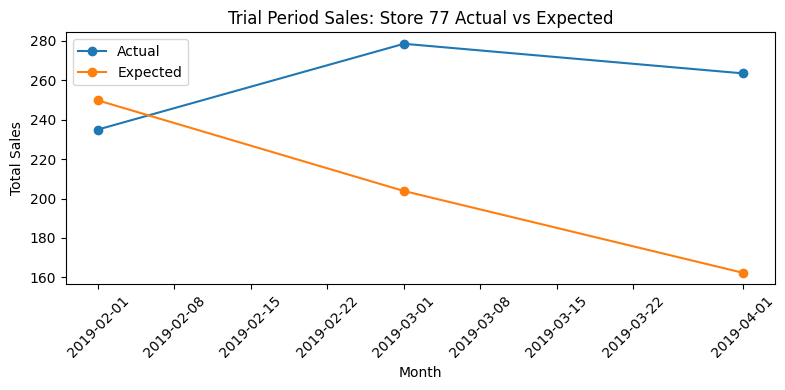

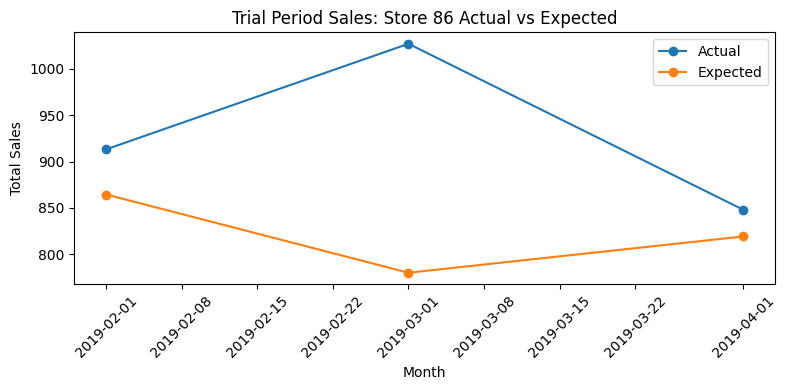

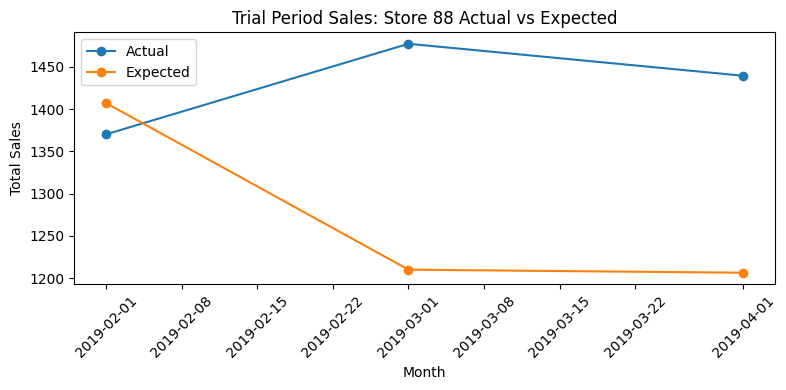

In [98]:
plot_actual_vs_expected(
    sales_trial_77_sig,
    "totSales_trial",
    "Trial Period Sales: Store 77 Actual vs Expected",
    "Total Sales"
)

plot_actual_vs_expected(
    sales_trial_86_sig,
    "totSales_trial",
    "Trial Period Sales: Store 86 Actual vs Expected",
    "Total Sales"
)

plot_actual_vs_expected(
    sales_trial_88_sig,
    "totSales_trial",
    "Trial Period Sales: Store 88 Actual vs Expected",
    "Total Sales"
)

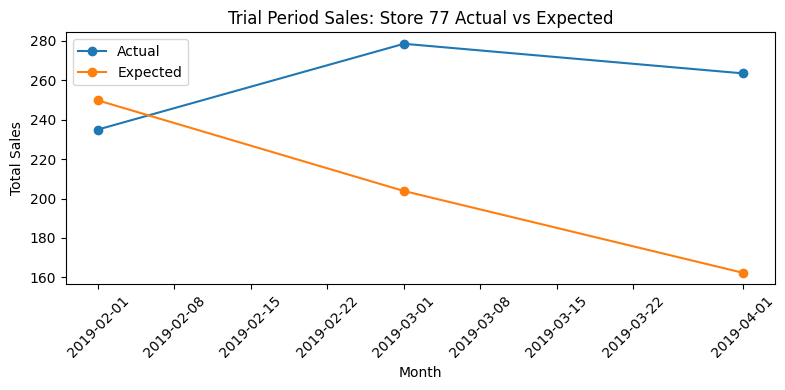

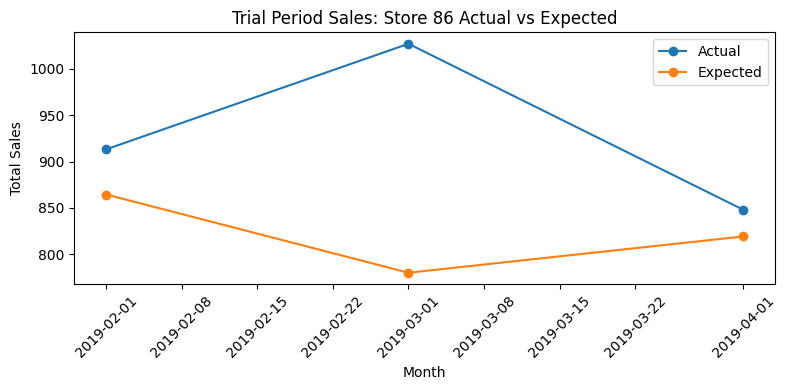

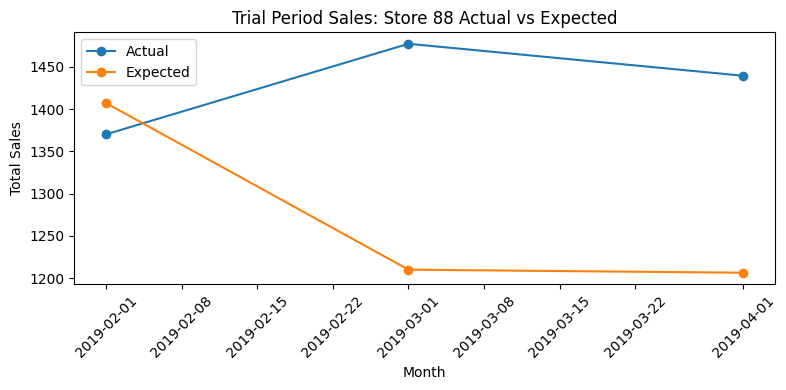

In [99]:
plot_actual_vs_expected(
    sales_trial_77_sig,
    "totSales_trial",
    "Trial Period Sales: Store 77 Actual vs Expected",
    "Total Sales"
)

plot_actual_vs_expected(
    sales_trial_86_sig,
    "totSales_trial",
    "Trial Period Sales: Store 86 Actual vs Expected",
    "Total Sales"
)

plot_actual_vs_expected(
    sales_trial_88_sig,
    "totSales_trial",
    "Trial Period Sales: Store 88 Actual vs Expected",
    "Total Sales"
)

## 11. Trial store results summary

### 11.1 Trial store 77

Store 77 shows the strongest evidence of a successful trial.

During the trial period:
- total sales were significantly above expected levels in March and April 2019
- customer numbers were also significantly above expected levels in March and April 2019

This suggests that the trial likely generated a genuine uplift in both sales and customer traffic for Store 77.

### 11.2 Trial store 86

Store 86 also shows evidence of a positive trial effect, although the result is weaker than that of Store 77.

During the trial period:
- total sales were significantly above expected levels in March 2019 only
- customer numbers were significantly above expected levels throughout February to April 2019

This suggests that the trial may have improved customer traffic in Store 86, but the sales uplift was less consistent across the full trial period.

### 11.3 Trial store 88

Store 88 shows some positive signs of uplift during the trial period.

During the trial period:
- total sales were significantly above expected levels in March and April 2019
- customer numbers were also significantly above expected levels in March and April 2019

However, the matched control for Store 88 was weaker than the control matches identified for Stores 77 and 86. Therefore, although the results are positive, they should be interpreted with greater caution.

## 12. Conclusion and recommendations

Overall, the trial appears to have been most successful in Store 77, where both sales and customer counts showed strong and sustained uplift during the trial period.

Store 86 also showed positive results, particularly in customer numbers, although the sales effect was less consistent. Store 88 showed some positive movement as well, but the result is less robust because the control store match was weaker.

Based on this analysis:
- Store 77 provides the clearest evidence that the trial layout had a positive impact
- Store 86 provides moderate supporting evidence
- Store 88 provides weaker but still positive evidence, which should be treated cautiously

From a business perspective, the trial results suggest that the new layout may be worth considering for broader rollout, especially if the implementation is similar to what was tested in Store 77.

However, before making a full rollout decision, it would be sensible to:
- review whether the same uplift can be replicated in additional stores
- confirm that the trial execution was consistent across locations
- continue measuring performance after the trial period to test whether the uplift is sustained over time

From a business perspective, the trial results suggest that the new layout may be worth considering for broader rollout, especially if the implementation is similar to what was tested in Store 77.

However, before making a full rollout decision, it would be sensible to:
- review whether the same uplift can be replicated in additional stores
- confirm that the trial execution was consistent across locations
- continue measuring performance after the trial period to test whether the uplift is sustained over time

This analysis is based on a relatively short pre-trial and trial period. In addition, the control match for Store 88 was weaker than for the other two trial stores.

Therefore, the results should be interpreted as strong practical evidence rather than perfectly conclusive proof.

The trial was most successful in Store 77, which showed strong and significant uplift in both total sales and customer numbers. Store 86 also showed positive trial results, particularly in customer traffic, although the sales impact was less consistent. Store 88 showed some positive uplift, but the result should be interpreted more cautiously due to a weaker control store match.